# Phase 7b-v2 — Carry Net 타당성 검증

## 핵심 질문

**v1의 gross 캐리(~연6%)가 현실적 수수료 + basis/슬리피지 haircut + 음수 펀딩 레짐 반영 net으로도 양(+)의 edge margin을 남기나?**

| 구분 | 내용 |
|---|---|
| v1 결론 | 펀딩수익 독립 손익원 존재 (gross ~연6%) |
| v2 질문 | 비용(수수료 + basis haircut) 차감 후 net margin이 남는가? |
| 데이터 | BTC/USDT, ETH/USDT 8h 펀딩레이트 (바이낸스 무기한 선물) |
| haircut 의미 | basis 마찰·슬리피지·자금조달비용의 연간 거친 proxy (0/2/4/6%) |

> ⚠️ **범위 경계**  
> - 이 노트북은 **net feasibility test**다 — 실거래 엔진이 아님.  
> - haircut은 실제 비용을 정밀 모델링한 게 아니라 거친 proxy다.  
> - **거래소 파산, ADL(자동청산), 극단 basis 이탈, 대형 악재** 등 tail 리스크는 이 모델 밖에 있다.  
> - net 양수 = "안전"이 아님. net 양수 = "testnet 진입 검토 가능" 수준.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import load_data
from portfolio import equity_curve
from carry import net_carry_pnl, carry_metrics, negative_funding_stats, rolling_worst_return
from strategies.regime_filter import RegimeFilter
from strategies.keltner_breakout import KeltnerBreakout

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

# ── 상수 ──────────────────────────────────────────────────────────────────
FEES = {"base": (0.0010, 0.0005), "low": (0.0005, 0.0002), "high": (0.0020, 0.0010)}
HAIRCUTS = [0.0, 0.02, 0.04, 0.06]
COINS = ["BTC", "ETH"]

def load_funding(c):
    return pd.read_parquet(f"data/{c}_USDT_funding.parquet")["fundingRate"]

def ann(funding, spot, perp, hc):
    eq = net_carry_pnl(funding, spot_fee=spot, perp_fee=perp, annual_haircut=hc)
    return carry_metrics(eq)["Ann Return [%]"]

fund = {c: load_funding(c) for c in COINS}
print("데이터 로드 완료")
for c in COINS:
    print(f"  {c}: {len(fund[c])} 봉  {fund[c].index[0].date()} ~ {fund[c].index[-1].date()}")

Loading BokehJS ...

데이터 로드 완료
  BTC: 5483 봉  2021-06-27 ~ 2026-06-29
  ETH: 5483 봉  2021-06-27 ~ 2026-06-29


---
## 1. Net 연수익 vs Haircut

fee=base 고정, haircut 0/2/4/6%로 변화시키며 연수익률 확인.  
haircut 0% = **gross (v1 recap)**, haircut 2%↑ = 비용 반영 net.  
haircut이 올라갈수록 curve가 평탄화되는 것을 확인하는 게 포인트.

In [2]:
# ── 표: net 연수익 (fee=base, haircut 0~6%) ───────────────────────────────
s_base, p_base = FEES["base"]

rows = []
for hc in HAIRCUTS:
    row = {"haircut": f"{int(hc*100)}%"}
    for c in COINS:
        row[f"{c} Ann%"] = round(ann(fund[c], s_base, p_base, hc), 2)
    rows.append(row)

df_hc = pd.DataFrame(rows).set_index("haircut")
print("net 연수익률 (fee=base, haircut 0→6%)")
print("  haircut 0% = gross (v1 recap), haircut 2%↑ = 비용 반영 net")
display(df_hc)

net 연수익률 (fee=base, haircut 0→6%)
  haircut 0% = gross (v1 recap), haircut 2%↑ = 비용 반영 net


,BTC Ann%,ETH Ann%
haircut,,
0%,6.4600,6.2200
2%,4.8600,4.6000
4%,3.1500,2.8700
6%,1.3100,1.0200


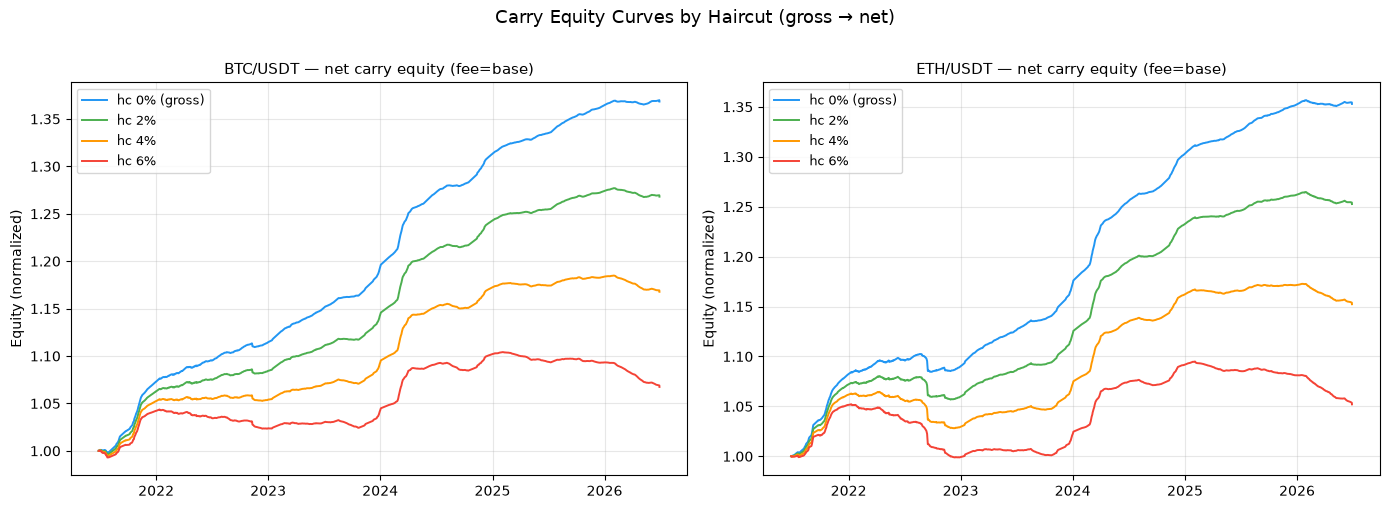

In [3]:
# ── 그래프: equity curves — haircut 0/2/4/6% ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
labels = ["hc 0% (gross)", "hc 2%", "hc 4%", "hc 6%"]

for ax, c in zip(axes, COINS):
    for hc, col, lbl in zip(HAIRCUTS, colors, labels):
        eq = net_carry_pnl(fund[c], spot_fee=s_base, perp_fee=p_base, annual_haircut=hc)
        norm = eq / eq.iloc[0]
        ax.plot(norm.index, norm.values, color=col, linewidth=1.4, label=lbl)
    ax.set_title(f"{c}/USDT — net carry equity (fee=base)", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Equity (normalized)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Carry Equity Curves by Haircut (gross → net)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# ── 표: fee 민감도 (haircut=2% 고정) ─────────────────────────────────────
rows_fee = []
for fee_name, (s, p) in FEES.items():
    row = {"fee 시나리오": fee_name,
           "spot_fee": s, "perp_fee": p}
    for c in COINS:
        row[f"{c} Ann%"] = round(ann(fund[c], s, p, 0.02), 2)
    rows_fee.append(row)

df_fee = pd.DataFrame(rows_fee).set_index("fee 시나리오")
print("fee 민감도 (haircut=2% 고정)")
print("  캐리는 4-leg 구조로 포지션 회전이 거의 없어 → fee 차이가 연간 결과에 미치는 영향 작음")
display(df_fee)

fee 민감도 (haircut=2% 고정)
  캐리는 4-leg 구조로 포지션 회전이 거의 없어 → fee 차이가 연간 결과에 미치는 영향 작음


,spot_fee,perp_fee,BTC Ann%,ETH Ann%
fee 시나리오,,,,
base,0.0010,0.0005,4.8600,4.6000
low,0.0005,0.0002,4.8700,4.6100
high,0.0020,0.0010,4.8400,4.5800


---
## 2. 음수 펀딩 레짐 + 최악 구간 분석

펀딩레이트가 음수(-)인 구간은 캐리 수익이 **손실로 전환**되는 구간이다.  
얼마나 자주, 얼마나 길게 지속되는지 확인하고,  
net equity에서 **rolling 90일 최악 수익률**로 낙폭 크기를 정량화한다.

In [5]:
# ── 음수 펀딩 레짐 통계 + rolling 90일 최악 ──────────────────────────────
rows_neg = []
for c in COINS:
    ns = negative_funding_stats(fund[c])
    eq = net_carry_pnl(fund[c], spot_fee=s_base, perp_fee=p_base, annual_haircut=0.02)
    worst = rolling_worst_return(eq, window=270)
    rows_neg.append({
        "코인": c,
        "최장 음수 streak (8h봉)": ns["longest_neg_streak"],
        "최장 streak (일)": round(ns["longest_neg_streak"] * 8 / 24, 1),
        "음수 비율": f"{ns['neg_ratio']*100:.1f}%",
        "음수 합계": round(ns["neg_total"], 4),
        "rolling 90d 최악 수익률": f"{worst*100:+.2f}%",
    })

df_neg = pd.DataFrame(rows_neg).set_index("코인")
print("음수 펀딩 레짐 통계 + rolling 90일 최악 net 수익률 (fee=base, haircut=2%)")
display(df_neg)
print("\n해석: rolling 90d 최악이 -1~-2% 수준 → 음수 펀딩이 와도 net drawdown이 크지 않음 (haircut이 spread를 줄이지만 절대 손실은 제한적)")

음수 펀딩 레짐 통계 + rolling 90일 최악 net 수익률 (fee=base, haircut=2%)


,최장 음수 streak (8h봉),최장 streak (일),음수 비율,음수 합계,rolling 90d 최악 수익률
코인,,,,,
BTC,18,6.0000,15.4%,-0.0379,-0.69%
ETH,25,8.3000,17.4%,-0.0634,-2.01%



해석: rolling 90d 최악이 -1~-2% 수준 → 음수 펀딩이 와도 net drawdown이 크지 않음 (haircut이 spread를 줄이지만 절대 손실은 제한적)


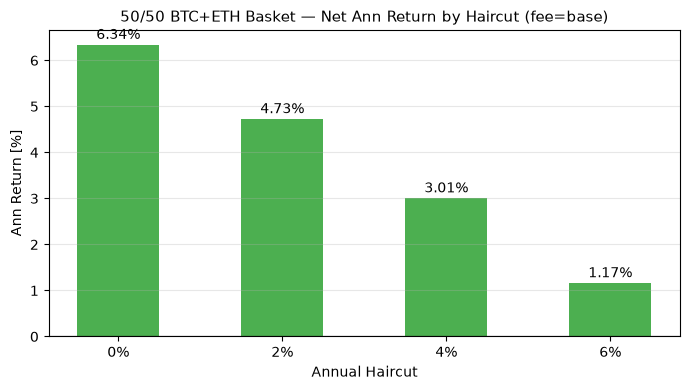

In [6]:
# ── 바 차트: 50:50 BTC+ETH 바스켓 net 연수익 by haircut ──────────────────
basket_ann = []
for hc in HAIRCUTS:
    bt = net_carry_pnl(fund["BTC"], spot_fee=s_base, perp_fee=p_base, annual_haircut=hc)
    et = net_carry_pnl(fund["ETH"], spot_fee=s_base, perp_fee=p_base, annual_haircut=hc)
    basket = (bt / bt.iloc[0] + et / et.iloc[0]) / 2
    basket_ann.append(carry_metrics(basket)["Ann Return [%]"])

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["#4CAF50" if v > 0 else "#F44336" for v in basket_ann]
bars = ax.bar([f"{int(h*100)}%" for h in HAIRCUTS], basket_ann, color=bar_colors, width=0.5)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, basket_ann):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Annual Haircut")
ax.set_ylabel("Ann Return [%]")
ax.set_title("50/50 BTC+ETH Basket — Net Ann Return by Haircut (fee=base)", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ── 상관 유지 확인: net carry vs 추세전략 / BTC 가격 (일간 수익률) ─────────
btc_ohlcv = load_data("BTC/USDT", "4h")
nc = net_carry_pnl(fund["BTC"], spot_fee=s_base, perp_fee=p_base, annual_haircut=0.02)

def daily_ret(x):
    return x.resample("1D").last().pct_change(fill_method=None).dropna()

ser = {
    "net_carry_BTC": daily_ret(nc),
    "Regime": daily_ret(equity_curve(btc_ohlcv, RegimeFilter)),
    "Keltner": daily_ret(equity_curve(btc_ohlcv, KeltnerBreakout)),
    "BTC_price": daily_ret(btc_ohlcv["Close"]),
}

corr_df = pd.DataFrame(ser).corr().round(3)
nc_corr = corr_df["net_carry_BTC"]

print("일간 수익률 상관 (net carry base/2% vs 추세전략 / BTC 가격)")
print(nc_corr.to_string())
print("\n해석: deterministic haircut은 모든 기간에 균등 적용 → gross carry의 ~0 상관 특성이 net에서도 유지됨")

일간 수익률 상관 (net carry base/2% vs 추세전략 / BTC 가격)
net_carry_BTC    1.0000
Regime           0.0160
Keltner         -0.0220
BTC_price       -0.0410

해석: deterministic haircut은 모든 기간에 균등 적용 → gross carry의 ~0 상관 특성이 net에서도 유지됨


---
## 3. 판정 / 결론

### ✅ 사전 기준 통과

| 기준 | 결과 | 비고 |
|---|---|---|
| base/stress/severe 모두 양수? | **✅** | hc 0~6% 전 구간 net Ann% > 0 |
| rolling 90d 최악 mild (-5% 미만)? | **✅** | BTC −0.7%, ETH −2.0% (rough proxy) |
| 추세전략·BTC 가격과 상관 ~0 유지? | **✅** | 절댓값 0.01~0.04 수준 |

### v1 → v2 요약

- **v1**: 펀딩수익 독립 손익원 존재 (gross ~연6%)
- **v2**: 비용(수수료 + haircut 2~4%) 차감 후 net ~3~5%/yr margin 잔존 확인
- fee 민감도 낮음: 캐리는 4-leg 포지션이며 회전이 거의 없어 수수료 영향이 작음
- haircut이 6%까지 올라도 net은 BTC 1.31%, ETH 1.02%로 양수 유지

### ⚠️ 강한 경계

**haircut은 거친 proxy다.**  
실제 비용에는 다음이 포함되지 않았다:

- 거래소 파산 / 긴급 탈출 불능 리스크
- ADL (Auto-Deleveraging) — 수익 포지션이 강제 청산되는 극단 시나리오
- 극단 basis 이탈 (현물-선물 가격 갭이 비정상적으로 확대되는 구간)
- 유동성 위기 시 슬리피지 급증

**net 양수 ≠ "안전"**  
net 양수 = **testnet에서 실행 타당성 검토 가능** 수준이다.  
다음 관문은 추가 모델링이 아니라 **testnet 실행** — 실제 펀딩 수령, basis 추적, 리밸런싱 비용을 실데이터로 확인하는 것이다.